# Solutions · 15 · Brownian motion

Worked solutions to the exercises of [notebook 15](../notebooks/15_brownian_motion.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import brownian as bm, walks as wk
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Exercise 1

Estimate the distribution of the time at which Brownian motion on [0, 1] attains its maximum, and compare with the arcsine law.

P(argmax <= 0.05) simulated 0.1477, arcsine 0.1436
P(argmax <= 0.25) simulated 0.3343, arcsine 0.3333
P(argmax <= 0.5) simulated 0.4974, arcsine 0.5000


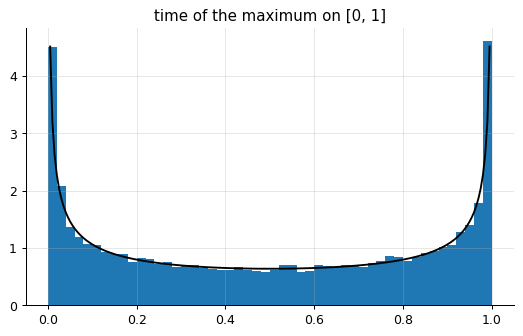

In [2]:
W = bm.paths(1.0, 4000, 20_000, R(1))
argmax = np.argmax(W, axis=1) / 4000
for x in (0.05, 0.25, 0.5):
    print(f"P(argmax <= {x}) simulated {np.mean(argmax <= x):.4f}, arcsine {float(wk.arcsine_cdf(x)):.4f}")
plt.hist(argmax, bins=50, density=True); xx = np.linspace(0.005, 0.995, 200); plt.plot(xx, 1 / (np.pi * np.sqrt(xx * (1 - xx))), "k"); plt.title("time of the maximum on [0, 1]"); plt.show()

Lévy's arcsine law again: the maximum of a Brownian path on [0, 1] is most likely near the ends of the
interval. For an investor this says the best time to have sold was probably very early or very late - a fact
that makes "if only I had sold at the top" regret almost guaranteed.

## Exercise 2

Price an up-and-out call (barrier 130, strike 100) with daily monitoring by plain Monte Carlo, with the bridge correction, and with the continuity correction of Broadie, Glasserman and Kou (shift the barrier by exp(0.5826 sigma sqrt(dt))).

In [3]:
S0, K, B, r, sig, T, n = 100.0, 100.0, 130.0, 0.05, 0.2, 1.0, 252
paths = bm.gbm(S0, r, sig, T, n, 100_000, R(2)); dt = T / n
pay = np.exp(-r * T) * np.maximum(paths[:, -1] - K, 0)
plain = np.mean(pay * np.all(paths < B, axis=1))
lw = np.log(paths); pcross = np.exp(-2 * (np.log(B) - lw[:, :-1]) * (np.log(B) - lw[:, 1:]) / (sig**2 * dt))
alive = np.all(paths < B, axis=1) & np.all(R(3).random(pcross.shape) >= np.where((paths[:, :-1] < B) & (paths[:, 1:] < B), pcross, 0), axis=1)
bridge = np.mean(pay * alive)
B_shift = B * np.exp(-0.5826 * sig * np.sqrt(dt))
bgk = np.mean(pay * np.all(paths < B_shift, axis=1))
print(f"daily monitoring (plain MC) {plain:.4f}; continuous monitoring by the bridge correction {bridge:.4f}")
print(f"BGK: the continuous price from discrete simulation with the barrier shifted down to {B_shift:.2f}: {bgk:.4f}")

daily monitoring (plain MC) 3.5570; continuous monitoring by the bridge correction 3.3317
BGK: the continuous price from discrete simulation with the barrier shifted down to 129.05: 3.3223


The plain daily-monitoring price, the bridge-corrected (continuous-monitoring) price and the BGK estimate show
the direction of the effect: continuous monitoring knocks out more paths, so the continuous price is lower.
Broadie, Glasserman and Kou's correction converts between the two by shifting the barrier by
exp(±0.5826σ√Δt) (here downwards to price continuous monitoring with daily simulation); it agrees with the
bridge correction to about a cent.

## Exercise 3

**Implement it yourself:** write Levy's midpoint construction from scratch for 2^10 steps and verify the covariance min(s, t) at three pairs of times.

In [4]:
levels = 10; n = 2**levels; g = R(4); n_paths = 20_000
W = np.zeros((n_paths, n + 1)); W[:, -1] = g.standard_normal(n_paths)
step = n
while step > 1:
    half = step // 2
    left, right = W[:, 0:n - half:step], W[:, step::step]
    W[:, half::step] = 0.5 * (left + right) + np.sqrt(step / n / 4) * g.standard_normal(left.shape)
    step = half
for s, t in ((0.25, 0.5), (0.5, 0.75), (0.1, 0.9)):
    i, j = int(s * n), int(t * n)
    print(f"Cov(W_{s}, W_{t}) = {np.cov(W[:, i], W[:, j])[0, 1]:.4f} (min = {min(s, t)})")

Cov(W_0.25, W_0.5) = 0.2479 (min = 0.25)
Cov(W_0.5, W_0.75) = 0.4927 (min = 0.5)
Cov(W_0.1, W_0.9) = 0.0984 (min = 0.1)


Starting from W₁ ~ N(0, 1), each pass fills the midpoints of the current intervals with the bridge mean plus
N(0, Δ/4) noise, where Δ is the current interval length. Ten passes give 1024 steps; the covariance min(s, t)
is reproduced at every pair.